Naučíme se optimalizovat funkce. Začneme od čisté implementace v Pythonu, zkusíme vyřešit problém v NumPy. Poté si ukážeme, jak postupně přejíj k jazykům nižší úrovně, jako je Fortran nebo C, a také si představíme balík Numba.
<!-- TEASER_END -->

In [1]:
%pylab inline
from IPython.display import Image

Populating the interactive namespace from numpy and matplotlib


## Základní koncepce optimalizace

Už víme, že Python je jazyk, ve kterém jde velice efektivně programovat. A díky balíkům, jako jsou NumPy, SciPy nebo SymPy jde velice rychle řešit různé vědecké úlohy. Je pochopitelné, že s takovouto mírou abstrakce může být výsledný program pomalejší, než kdyby byl dobře napsán v nějakém kompilovaném jazyce typu C/C++ nebo Fortran. Musíme si ovšem uvědomit, že efektivita programu se měří v *celkovém čase stráveném na vývoji a běhu programu* (pro daný soubor úloh). Schématicky můžeme znázornit závislost rychlosti běhu programu v závislosti na délce vývoje asi takto:

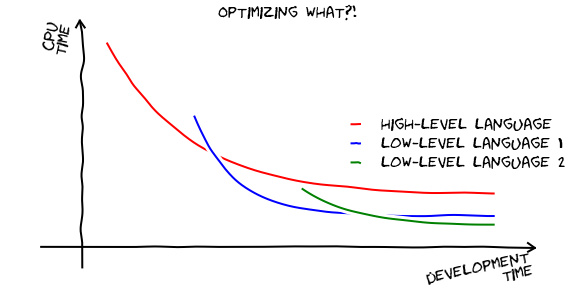

In [2]:
Image(filename='optimizing-what.png')

Všimněte si například, že typicky existuje nějaký offset ve vývojovém čase, tj. trvá nám déle v nízkoúrovňovém jazyce, než vůbec dostaneme první výsledek. Potřeba optimalizace tedy *silně závisí na objemu výpočtů, které budeme s daným programem řešit*.

Toto ovšem *neznamená, že pokud je objem velký, máme hned začít programovat v C nebo Fortranu*. Za chvíli si ukážeme, jak optimalizaci řešit chytřeji a postupně. Empirické pravidlo říká, že 90 % výpočetního času zabere 10 % zdrojového kódu. Je tedy vhodné nejprve těchto 10 % najít a poté je teprve začít optimalizovat. Python nám k tomuto účelu poskytuje velice mocné nástroje.

## Profilování

Profilování je nástroj, který nám umožní najít kritická místa v našem programu, oněch 10 %, které stojí za to optimalizovat. Zkusme si to ukázat na jednoduchém příkladu.

In [3]:
def heavy_calc(X):
    from numpy.fft import fft
    Y = X.copy()
    for i in range(10):
        Y = Y**i
    return Y

def heavy_loop(inputs):
    res = []
    for X in inputs:
        res.append(heavy_calc(X))
    return res

def code_setup():
    from numpy.random import rand
    N = 20
    M = 1000
    print("Will generate {} random arrays".format(N))
    inputs = [rand(M, M) for n in range(N)]
    print("Will calculate now")
    result = heavy_loop(inputs)
    print("Finished calculation")

Python obsahuje dva základní mofuly pro profilování - `profile` a `cProfile`, z nichž ten druhý je rychlejší. Pomocí funkce `run` pustíme výpočet pod dohledem cProfile, výsledky uložíme do souboru.

In [4]:
import cProfile
cProfile.run('code_setup()', 'pstats')

Will generate 20 random arrays
Will calculate now
Finished calculation


Dále budeme potřebovat modul `pstats`, který nám umožní s výsledky pracovat. Použije k tomu třídu `Stats`.

In [5]:
from pstats import Stats
p = Stats('pstats')

`print_stats` nám zobrazí prvních n záznamů.

In [6]:
p.print_stats(10)

Wed Dec 14 07:33:54 2016    pstats

         246 function calls in 7.142 seconds

   Random listing order was used
   List reduced from 26 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        6    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
        1    0.000    0.000    0.000    0.000 {method 'format' of 'str' objects}
        9    0.000    0.000    0.000    0.000 /opt/anaconda3/lib/python3.5/threading.py:1060(_wait_for_tstate_lock)
        9    0.000    0.000    0.000    0.000 /opt/anaconda3/lib/python3.5/threading.py:1102(is_alive)
        9    0.000    0.000    0.000    0.000 /opt/anaconda3/lib/python3.5/site-packages/ipykernel/iostream.py:89(_event_pipe)
       20    0.000    0.000    0.000    0.000 {method 'append' of 'list' objects}
        1    0.000    0.000    6.717    6.717 <ipython-input-3-8adda7c0d8fa>:8(heavy_loop)
        6    0.000    0.000    0.002    0.000 /opt/anaconda3/lib/python3.5

Ty jsou ovšem nesetříděné. Následující výstup už je užitečnější, záznamy jsou totiž setříděné podle celkového času stráveného v dané funkci. Navíc `strip_dirs` odstraní adresáře ze jmen funkcí.

In [7]:
p.strip_dirs().sort_stats('cumulative').print_stats(10)

Wed Dec 14 07:33:54 2016    pstats

         246 function calls in 7.142 seconds

   Ordered by: cumulative time
   List reduced from 26 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    7.142    7.142 {built-in method builtins.exec}
        1    0.013    0.013    7.142    7.142 <string>:1(<module>)
        1    0.000    0.000    7.129    7.129 <ipython-input-3-8adda7c0d8fa>:14(code_setup)
        1    0.000    0.000    6.717    6.717 <ipython-input-3-8adda7c0d8fa>:8(heavy_loop)
       20    6.676    0.334    6.716    0.336 <ipython-input-3-8adda7c0d8fa>:1(heavy_calc)
        1    0.000    0.000    0.410    0.410 <ipython-input-3-8adda7c0d8fa>:19(<listcomp>)
       20    0.410    0.020    0.410    0.020 {method 'rand' of 'mtrand.RandomState' objects}
       20    0.041    0.002    0.041    0.002 {method 'copy' of 'numpy.ndarray' objects}
        3    0.000    0.000    0.002    0.001 {built-in method bui

Takto vypadá výstup setříděný pomocí nekumulovaného času.

In [8]:
p.sort_stats('time').print_stats(10)

Wed Dec 14 07:33:54 2016    pstats

         246 function calls in 7.142 seconds

   Ordered by: internal time
   List reduced from 26 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       20    6.676    0.334    6.716    0.336 <ipython-input-3-8adda7c0d8fa>:1(heavy_calc)
       20    0.410    0.020    0.410    0.020 {method 'rand' of 'mtrand.RandomState' objects}
       20    0.041    0.002    0.041    0.002 {method 'copy' of 'numpy.ndarray' objects}
        1    0.013    0.013    7.142    7.142 <string>:1(<module>)
        9    0.002    0.000    0.002    0.000 {built-in method posix.urandom}
        9    0.001    0.000    0.002    0.000 iostream.py:180(schedule)
        1    0.000    0.000    6.717    6.717 <ipython-input-3-8adda7c0d8fa>:8(heavy_loop)
       21    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:996(_handle_fromlist)
        1    0.000    0.000    0.410    0.410 <ipython-input-3-8adda7c0d8fa>:19(<l

Z obou výstupů celkem jasně vydíme, že naprostou většinu času trávíme ve funkci `heavy_calc`. Pokud se tedy chceme pustit do optimalizace, musíme se zaměřit právě na tuto část našeho programu.

Výsledky můžete navíc spojit s nástroji pro vizualizaci, např.[SnakeViz](http://jiffyclub.github.io/snakeviz/), [RunSnakeRun](http://www.vrplumber.com/programming/runsnakerun/), nebo [pycallgraph](http://pycallgraph.slowchop.com/).

## Vzorová úloha - vzdálenost množiny bodů ve vícerozměrném prostoru

(Tento příklad byl převzat z http://jakevdp.github.io/blog/2013/06/15/numba-vs-cython-take-2.)

Zadání je jednoduché: pro M bodů v N rozměrném prostoru spočítejte vzájemnou vzdálenost $d$, která je pro dva body $x,y$ definovaná jako $\sqrt {\sum_{i=1}^N {{{\left( {{x_i} - {y_i}} \right)}^2}} } $. Výslekem je tedy (symetrická) matice $M\times M$.

In [9]:
# toto nechť jsou naše vstupní data
M = 1000
N = 3
X = np.random.random((M, N))

### Implementace v čistém Pythonu
Nemůžeme asi očekávat, že toto bude nejrychlejší a nejsnadnější verze našeho programu. Přesto stojí za to ji vyzkoušet, navíc ji budeme ještě potřebovat.

In [10]:
def pairwise_python(X):
    M = X.shape[0]
    N = X.shape[1]
    D = np.empty((M, M), dtype=np.float)
    for i in range(M):
        for j in range(M):
            d = 0.0
            for k in range(N):
                tmp = X[i, k] - X[j, k]
                d += tmp * tmp
            D[i, j] = np.sqrt(d)
    return D

Tahle funkce nám bude pomáhat ukládat výsledné časy z `%timeit`.

In [15]:
def get_time_timeit(stdout):
    """Get time from %timeit stdout output
    """
    from quantities import Quantity
    wrds = stdout.strip().split()
    i0 = wrds.index('per')
    t = Quantity(float(wrds[i0 - 2]), wrds[i0 - 1])
    t.units = 'ms'
    return t

Do `pairwise_times` si uložíme výsledné časy.

In [16]:
from collections import OrderedDict
pairwise_times = OrderedDict()

In [17]:
%%capture t_out
%timeit pairwise_python(X)

In [18]:
print(t_out.stdout)
pairwise_times['python'] = get_time_timeit(t_out.stdout)

1 loop, best of 3: 4.13 s per loop



### To samé pomocí NumPy
V případě NumPy můžeme v tomto případě využít broadcasting. Celá funkce tak zabere jeden rádek.

In [19]:
def pairwise_numpy(X):
    return np.sqrt(((X[:, newaxis, :] - X) ** 2).sum(-1))

In [20]:
%%capture t_out
%timeit pairwise_numpy(X)

In [21]:
print(t_out.stdout)
pairwise_times['numpy'] = get_time_timeit(t_out.stdout)

10 loops, best of 3: 49.9 ms per loop



Vidíme, že jsme zkrátili běh programu více než 100-krát. To není špatné, navíc je implementace daleko jednodušší.

### Přichází Cython

Cython je nástroj, který z Python programu, obohaceného o nějaké Cython direktivy, vytvoří program v C, který je možné zkompilovat a okamžitě použít jako modul v Pythonu. Typickým příkladem Cython direktiv jsou statické typy. Cython samozřejmě umožňuje používat funkce z binárních knihoven s C rozhraním.

Zkusíme optimalizovat naší funkci pairwise_python.

* Cython zdroják má koncovku .pyx (za začátku byl Pyrex).
* Cython dokáže přeložit jakýkoli Python. Výsledkem je ale minimální (nebo spíš žádná) optimalizace.
* `cimport` je analogie `import`, pracuje ale s Cython definicemi funkcí (.pxd soubory).
* Cython dodává `numpy.pyx`, obsahující dodatečné informace pro kompilace NumPy modulů. Proto voláme `cimport numpy`.
* Podobně `libc` je speciální modul Cythonu.

* Funkce se deklarují (moho deklarovat) se statickými typy vstupních parametrů. My použijeme `np.ndarray[np.float64_t, ndim=2]`.
* Proměnné se deklarují pomocí `cdef`.


In [22]:
%%file cyfuncs.pyx
import numpy as np
# numpy pro Cython
cimport numpy as np
from libc.math cimport sqrt

# tohle je čistý Python
def pairwise0(X):
    M = X.shape[0]
    N = X.shape[1]
    D = np.empty((M, M), dtype=np.float)
    for i in range(M):
        for j in range(M):
            d = 0.0
            for k in range(N):
                tmp = X[i, k] - X[j, k]
                d += tmp * tmp
            D[i, j] = np.sqrt(d)
    return D

# tady už začínáme optimalizovat, změny ale nejsou drastické
def pairwise1(np.ndarray[np.float64_t, ndim=2] X):
    cdef int M = X.shape[0]
    cdef int N = X.shape[1]
    cdef double tmp, d
    cdef np.ndarray D = np.empty((M, M), dtype=np.float64)
    for i in range(M):
        for j in range(M):
            d = 0.0
            for k in range(N):
                tmp = X[i, k] - X[j, k]
                d += tmp * tmp
            D[i, j] = sqrt(d)
    return D

Writing cyfuncs.pyx


In [39]:
%%file setup.py

from distutils.core import setup
from Cython.Build import cythonize
import numpy

setup(
  name='cyfuncs',
  include_dirs=[numpy.get_include()],
  ext_modules=cythonize("cyfuncs.pyx"),
)

Overwriting setup.py


In [33]:
!python setup.py build_ext --inplace

/opt/anaconda3/lib/python3.5/site-packages/Cython/Distutils/old_build_ext.py:30: UserWarning: Cython.Distutils.old_build_ext does not properly handle dependencies and is deprecated.
  "Cython.Distutils.old_build_ext does not properly handle dependencies "
running build_ext
building 'cyfuncs' extension
gcc -pthread -Wno-unused-result -Wsign-compare -DNDEBUG -g -fwrapv -O3 -Wall -Wstrict-prototypes -fPIC -I/opt/anaconda3/lib/python3.5/site-packages/numpy/core/include -I/opt/anaconda3/include/python3.5m -c cyfuncs.c -o build/temp.linux-x86_64-3.5/cyfuncs.o
In file included from /opt/anaconda3/lib/python3.5/site-packages/numpy/core/include/numpy/ndarraytypes.h:1777:0,
                 from /opt/anaconda3/lib/python3.5/site-packages/numpy/core/include/numpy/ndarrayobject.h:18,
                 from /opt/anaconda3/lib/python3.5/site-packages/numpy/core/include/numpy/arrayobject.h:4,
                 from cyfuncs.c:406:
/opt/anaconda3/lib/python3.5/site-packages/numpy/core/include/numpy/npy_1

Jak jsme již říkali, Cython vytvoří C zdroják, který se pak kompiluje pomocí běžného překladače (např. gcc). Pojďme se na tento soubor podívat.

In [34]:
from IPython.display import FileLink
FileLink('cyfuncs.c')

/home/jurban/workspace/python_fjfi/numerical_python_course/lecture_notes.cz/cyfuncs.c

Ten soubor je dlouhý ... Obsahuje spoustu Python "balastu", na kterém vidíme, jak je vlastně samotný CPython naprogramován. Naštěstí tento soubor obsahuje i komentáře, které říkají, které řádce daný blok odpovídá. Např.

     /* "cyfuncs.pyx":16
      *                 tmp = X[i, k] - X[j, k]
      *                 d += tmp * tmp
      *             D[i, j] = np.sqrt(d)             # <<<<<<<<<<<<<<
      *     return D
      * 
      */


In [35]:
import cyfuncs

In [36]:
print("cyfuncs obsahuje: " + ", ".join((d for d in dir(cyfuncs) if not d.startswith("_"))))

cyfuncs obsahuje: np, pairwise0, pairwise1


Podívejme se, jestli dostávám stále stejné výsledky.

In [37]:
allclose(cyfuncs.pairwise1(X), pairwise_numpy(X))

True

No a jak jsme na tom s časem?

In [38]:
%%capture t_out
%timeit cyfuncs.pairwise0(X)

In [40]:
print(t_out.stdout)
pairwise_times['cython0'] = get_time_timeit(t_out.stdout)

1 loop, best of 3: 3.57 s per loop



In [41]:
%%capture t_out
%timeit cyfuncs.pairwise1(X)

In [42]:
print(t_out.stdout)
pairwise_times['cython1'] = get_time_timeit(t_out.stdout)

10 loops, best of 3: 148 ms per loop



#### IPython %%cython magic

IPython, tak jako v mnoha jiných případech, nám práci s Cythonem usnadňuje pomocí triku `%%cython`. Zkusíme ho použít. Zároveň zkusíme ještě více náš kód optimalizovat, zatím je totiž pomalejší než numpy.

In [43]:
%load_ext Cython

In [44]:
%%cython
import numpy as np
cimport numpy as np
cimport cython
from libc.math cimport sqrt

@cython.boundscheck(False)
@cython.wraparound(False)
def pairwise_cython(double[:, ::1] X):
    cdef int M = X.shape[0]
    cdef int N = X.shape[1]
    cdef double tmp, d
    cdef double[:, ::1] D = np.empty((M, M), dtype=np.float64)
    for i in range(M):
        for j in range(M):
            d = 0.0
            for k in range(N):
                tmp = X[i, k] - X[j, k]
                d += tmp * tmp
            D[i, j] = sqrt(d)
    return np.asarray(D)

In [45]:
allclose(pairwise_cython(X), pairwise_numpy(X))

True

In [46]:
%%capture t_out
%timeit pairwise_cython(X)

In [47]:
print(t_out.stdout)
pairwise_times['cython2'] = get_time_timeit(t_out.stdout)

100 loops, best of 3: 6.98 ms per loop



Tohle je už konečně výrazné zrychlení oproti NumPy.

#### Cython toho nabízí mnoho
Podívejte se na http://docs.cython.org co všechno Cython nabízí -- není toho málo, např.

* použití C++
* šablony (templates)
* OpenMP (k tomu se možná ještě dostaneme)
* vytváření C-API
* třídy (cdef classes)

### Z Fortranu (nebo C) do Pythonu pomocí F2PY

F2PY je nástroj, který byl v podstatě vytvořen pro NumPy a SciPy, protože, jak dobře víme, tyto moduly volají externí knihovny napsané ve Fortrane nebo C. Dokumentaci (trochu zastaralou) najdeme [zde](http://cens.ioc.ee/projects/f2py2e/usersguide/index.html). Bylo tedy velice výhodné vytvořit nástroj, který toto usnadní. A tak se zrodilo F2PY. Ve zkratce, F2PY umožňuje velice jednoduše z Fortran nebo C funkcí vytvořit Python modul. Využívá navíc vlastností NumPy pro předávání vícerozměnrých polí. 

Poďme chvilku programovat ve Fortranu :)

In [48]:
%%file pairwise_fort.f90

subroutine pairwise_fort(X, D, m, n)
    integer :: n,m
    double precision, intent(in) :: X(m, n)
    double precision, intent(out) :: D(m, m) 
    integer :: i, j, k
    double precision :: r 
    
    do j = 1,m 
        do i = 1,m 
            r = 0
            do k = 1,n 
                r = r + (X(i,k) - X(j,k)) * (X(i,k) - X(j,k)) 
            end do 
            D(i,j) = sqrt(r) 
        end do 
    end do 
end subroutine pairwise_fort

Writing pairwise_fort.f90


Z čeho f2py bere informace o vytvoření modulu?

1. Pole (double precision) převádí na numpy array.
2. `intent(in)` = vstupní argument.
3. `intent(out)` = výstupní argument.
4. f2py schová explicitně zadané rozměry polí (m, n).

Pokud bychom programovali v C, je potřeba dodat f2py nějaké informace navíc, neboť např. intent v C neexistuje. 

Tento soubor přeložíme pomocí `f2py`:

In [50]:
!f2py -c pairwise_fort.f90 -m pairwise_fort > /dev/null

`-m pairwise_fort` je požadované jméno modulu. Můžeme ho rovnou importovat, resp. jeho stejnojmennou funkci.

In [51]:
from pairwise_fort import pairwise_fort
print(pairwise_fort.__doc__)

d = pairwise_fort(x,[m,n])

Wrapper for ``pairwise_fort``.

Parameters
----------
x : input rank-2 array('d') with bounds (m,n)

Other Parameters
----------------
m : input int, optional
    Default: shape(x,0)
n : input int, optional
    Default: shape(x,1)

Returns
-------
d : rank-2 array('d') with bounds (m,m)



Fortran a C používají jiné uspořádání paměti pro ukládání vícerozměrných polí. Fortran je "column-major" zatímco C je "row-major". NumPy dokáže pracovat s obojím a pro uživatele je to obvykle jedno. Pokud ovšem chceme předat vícerozměrné pole do Fortran funkce, je lepší mít prvky uložené v paměti jako to dělá Fortran. V takovém případě totiž f2py předá pouze referenci (ukazatel) na dané místo v paměti. V opačném případě f2py nejprve pole musí transponovat, tj. *vytvořit kopii* s jiným uspořádáním, což může být samozřejmě náročné na pamět a procesor.

Vytvoříme si proměnnou XF, která má Fortran uspořádání, pomocí `numpy.asfortranarray` (prozaický název :)

In [52]:
XF = np.asfortranarray(X)

Vyzkoušíme, jestli stále dostáváme stejné výsledky.

In [53]:
allclose(pairwise_fort(XF), pairwise_numpy(X))

True

No a konečně se můžeme podívat, jak je to s rychlostí ...

In [54]:
%%capture t_out
%timeit pairwise_fort(XF)

In [55]:
print(t_out.stdout)
pairwise_times['fortran'] = get_time_timeit(t_out.stdout)

100 loops, best of 3: 6.2 ms per loop



## Představuje se `numba`

Numba kompiluje Python kód pomocí [LLVM](http://llvm.org/). Podporujme just-in-time kompilaci pomocí dekorátorů `jit` a `autojit`. Druhý jmenovaný je obzvlášť jednoduchý na použití.

In [56]:
from numba.decorators import autojit

pairwise_numba = autojit(pairwise_python)

Tradiční kontrola. Po prvním spuštění navíc Numba funkci poprvé zkompiluje.

In [57]:
allclose(pairwise_numba(X), pairwise_numpy(X))

True

Jaký čas od takto "jednoduché" optimalizace můžeme očekávat?

In [58]:
%%capture t_out
%timeit pairwise_numba(X)

In [59]:
print(t_out.stdout)
pairwise_times['numba'] = get_time_timeit(t_out.stdout)

100 loops, best of 3: 4.95 ms per loop



Vidíme, že zrychlení vůbec není špatné. Zvlášť když vezmemem v úvahu, že jsme toho dosáhli jediným řádkem (kromě importů).

## Srovnání výsledků

Výsledky můžeme porovnat pomocí grafu.

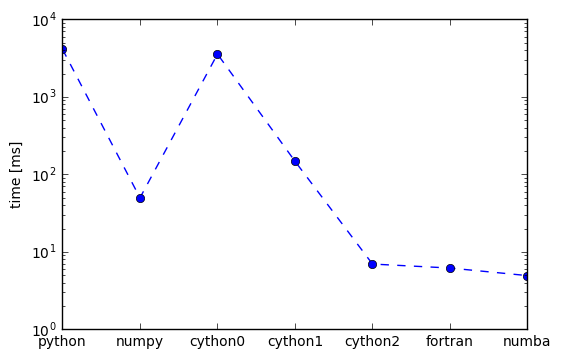

In [60]:
fig, ax = subplots()
values = np.array([t.magnitude[()] for t in pairwise_times.values()])
ax.semilogy(values, 'o--')
ax.set_xticklabels(tuple(pairwise_times.keys()))
ax.set_ylabel('time [ms]')

## Další možnosti

* Vestavěný modul [`ctypes`](http://docs.python.org/2/library/ctypes.html) dovoluje volat funkce z externích dynamických knihoven. Pro použití s NumPy viz [Cookbook](http://wiki.scipy.org/Cookbook/Ctypes).
* [`scipy.weave`](http://docs.scipy.org/doc/scipy/reference/tutorial/weave.html) umožňuje just-in-time kompilaci C/C++ kódu.
* [SWIG](http://www.swig.org/) jde použít pro propojení s mnoha jazyky.


### Cvičení

Obdobný postup aplikujte na výpočet kumulativního součtu, který je definovaný jako

$\displaystyle
S_j = \sum\limits_{i = 1}^j x_i $